# MATH 212: Movie Recommendation System

## Similarity & Recommendation Engine

This notebook covers the core algorithm for finding nearest neighbours and generating personalised recommendations using linear algebra.

**Objectives:**

- Clean the dataset to get a matrix of ratings
- Compute Euclidean distances between user rating vectors in $\mathbb{R}^{n}$.
- Identify the $k=5$ nearest neighbours for a target user.
- Generate and rank movie recommendations based on neighbour averages.

### 1. Dataset cleaning

In [ ]:
import pandas as pd
import numpy as np


ratings = pd.read_csv("archive/ratings.csv")
movies = pd.read_csv("archive/movies.csv")

print("=" * 60)
print("Original Dataset")
print("=" * 60)

print(f"Number of ratings : {len(ratings)}")
print(f"Number of users   : {ratings['userId'].nunique()}")
print(f"Number of movies  : {ratings['movieId'].nunique()}")


selected_users = sorted(ratings["userId"].unique())[:40]

ratings = ratings[ratings["userId"].isin(selected_users)]

print("\nUsers Selected:", len(selected_users))


selected_movies = ratings["movieId"].value_counts().head(20).index

ratings = ratings[ratings["movieId"].isin(selected_movies)]

print("Movies Selected:", len(selected_movies))


ratings_matrix = ratings.pivot(index="userId", columns="movieId", values="rating")

ratings_matrix = ratings_matrix.fillna(0)

ratings_matrix = ratings_matrix.reindex(
    index=selected_users, columns=selected_movies, fill_value=0
)


movie_titles = movies.set_index("movieId")["title"]

ratings_matrix.columns = [
    movie_titles.get(movie, f"Movie {movie}") for movie in ratings_matrix.columns
]


ratings_numpy = ratings_matrix.to_numpy()


print("\n" + "=" * 60)
print("Ratings Matrix Information")
print("=" * 60)

print("Matrix Shape:", ratings_numpy.shape)

print("\nRows represent:")
print("Users")

print("\nColumns represent:")
print("Movies")

print("\nEntries represent:")
print("Movie ratings from 1–5")
print("0 means the user has not rated the movie.")


print("\nFirst Five Rows")
print(ratings_matrix.head())

total_entries = ratings_numpy.size

rated_entries = np.count_nonzero(ratings_numpy)

missing_entries = total_entries - rated_entries

sparsity = (missing_entries / total_entries) * 100

print("\n" + "=" * 60)
print("Matrix Statistics")
print("=" * 60)

print(f"Total entries        : {total_entries}")
print(f"Ratings available    : {rated_entries}")
print(f"Missing ratings (0s) : {missing_entries}")
print(f"Sparsity             : {sparsity:.2f}%")


output_file = "data_cleaned.csv"

ratings_matrix.to_csv(output_file)

print("\nCleaned dataset saved as:")
print(output_file)

Original Dataset
Number of ratings : 100836
Number of users   : 610
Number of movies  : 9724

Users Selected: 40
Movies Selected: 20

Ratings Matrix Information
Matrix Shape: (40, 20)

Rows represent:
Users

Columns represent:
Movies

Entries represent:
Movie ratings from 1–5
0 means the user has not rated the movie.

First Five Rows
        Pulp Fiction (1994)  Forrest Gump (1994)  \
userId                                             
1                       3.0                  4.0   
2                       0.0                  0.0   
3                       0.0                  0.0   
4                       1.0                  0.0   
5                       5.0                  0.0   

        Shawshank Redemption, The (1994)  \
userId                                     
1                                    0.0   
2                                    3.0   
3                                    0.0   
4                                    0.0   
5                                  

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Data Loading and Matrix Initialization

First, we load the cleaned dataset provided by Salma into a pandas DataFrame. We then convert this into a NumPy matrix to efficiently perform our vector operations. The matrix has dimensions $m \times n$, where $m$ is the number of users and $n$ is the number of movies.


In [12]:
df = pd.read_csv("data_cleaned.csv", index_col=0)
A = df.to_numpy()

print(f"Matrix initialized with shape: {A.shape} (Users x Movies)")

Matrix initialized with shape: (40, 20) (Users x Movies)


### 2. Methodology: Computing Euclidean Distance

To determine how similar two users are, we treat their ratings as vectors and calculate the Euclidean distance between them. A smaller distance indicates that the users have similar tastes.

The formula used is:
$$d(u, v) = \sqrt{\sum_{i=1}^{n} (u_i - v_i)^2}$$

We utilize `numpy.linalg.norm` to compute this efficiently.


In [13]:
# Calculate the Euclidean distance between two user vectors.
def compute_euclidean_distance(user_u, user_v):
    return np.linalg.norm(user_u - user_v)

### 3. Methodology: Finding $k$-Nearest Neighbours

For a given target user, we calculate the Euclidean distance to all other users in the matrix. We then sort these distances in ascending order and select the top $k=5$ users. These form the "trusted advisors" for our recommendations.


In [14]:
# Identifies the k nearest users based on Euclidean distance.
def get_k_nearest_neighbours(target_user_id, ratings_df, k=5):
    target_vector = ratings_df.loc[target_user_id].to_numpy()
    distances = []

    for user_id in ratings_df.index:
        if user_id != target_user_id:
            peer_vector = ratings_df.loc[user_id].to_numpy()
            dist = compute_euclidean_distance(target_vector, peer_vector)
            distances.append((user_id, dist))

    # Sort by distance (ascending)
    distances.sort(key=lambda x: x[1])

    return distances[:k]

### 4. Methodology: Generating Recommendations

Once the $k=5$ neighbours are identified, the system isolates the movies the target user has **not** rated (value of 0.0). For each unrated movie, it calculates the average rating given by the nearest neighbours. The unrated movies are then ranked in descending order based on this predicted score.


In [15]:
# Predicts scores for unrated movies by averaging neighbour ratings, then returns a ranked list.
def generate_recommendations(target_user_id, neighbours, ratings_df):
    target_ratings = ratings_df.loc[target_user_id]
    neighbour_ids = [n[0] for n in neighbours]
    neighbour_ratings = ratings_df.loc[neighbour_ids]

    recommendations = []

    for movie in ratings_df.columns:
        if target_ratings[movie] == 0.0:
            scores = neighbour_ratings[movie].to_numpy()

            # Compute average rating from neighbours
            avg_score = np.mean(scores)

            if avg_score > 0:
                recommendations.append((movie, avg_score))

    # Rank unrated items by predicted score (highest to lowest)
    recommendations.sort(key=lambda x: x[1], reverse=True)
    return recommendations

### 5. Results: Testing on Target Users

As outlined in the project requirements, the system is tested on 3 distinct target users. The outputs below detail the selected nearest neighbours and the resulting top movie recommendations, which will be discussed in Section 4 of the final report.


In [16]:
# Testing on 3 different target users
test_users = [1, 12, 35]

for user in test_users:
    print(f" TARGET USER: {user} ")
    neighbours = get_k_nearest_neighbours(user, df, k=5)

    print("Top 5 Nearest Neighbours (User ID, Distance):")
    for n in neighbours:
        print(f"  User {n[0]}: {n[1]:.2f}")

    recs = generate_recommendations(user, neighbours, df)

    print("\nTop Movie Recommendations:")
    if not recs:
        print("  No recommendations available.")
    else:
        for movie, score in recs[:5]:
            print(f"  {movie}: {score:.2f} predicted rating")
    print("\n")

 TARGET USER: 1 
Top 5 Nearest Neighbours (User ID, Distance):
  User 28: 8.54
  User 18: 10.14
  User 39: 11.58
  User 17: 11.67
  User 16: 11.72

Top Movie Recommendations:
  Shawshank Redemption, The (1994): 3.50 predicted rating
  Terminator 2: Judgment Day (1991): 3.50 predicted rating
  Lord of the Rings: The Fellowship of the Ring, The (2001): 3.10 predicted rating
  Aladdin (1992): 1.50 predicted rating
  Apollo 13 (1995): 0.70 predicted rating


 TARGET USER: 12 
Top 5 Nearest Neighbours (User ID, Distance):
  User 3: 0.50
  User 36: 4.00
  User 2: 5.00
  User 23: 5.32
  User 9: 7.07

Top Movie Recommendations:
  Shawshank Redemption, The (1994): 1.40 predicted rating
  Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981): 1.00 predicted rating
  Lord of the Rings: The Fellowship of the Ring, The (2001): 1.00 predicted rating
  Usual Suspects, The (1995): 0.80 predicted rating
  Gladiator (2000): 0.80 predicted rating


 TARGET USER: 35 
Top 5 Nearest

<Axes: >

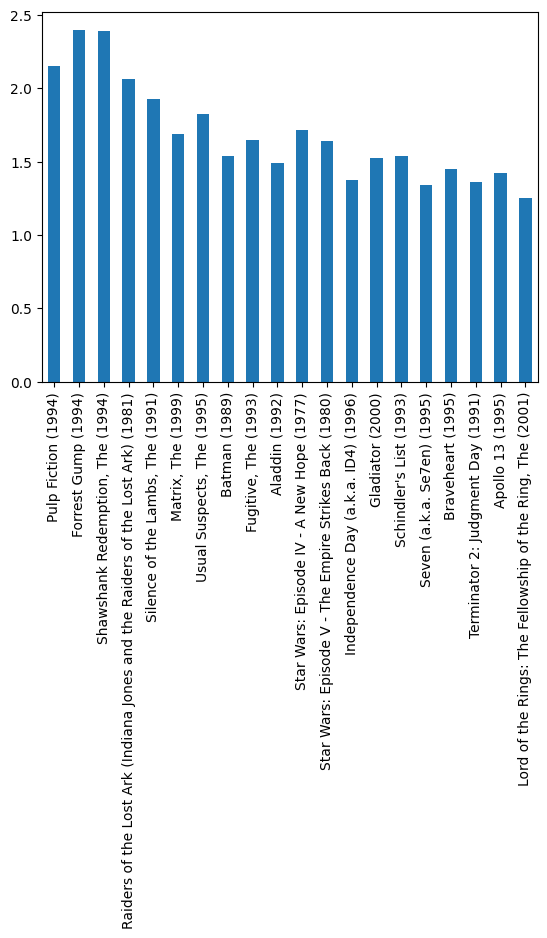

In [17]:
item_averages = df.mean(axis=0)  # average down each column
item_averages.plot(kind='bar')